<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ICS40125 - Laboratorio N°10

**Objetivo**: Analizar y modelar series temporales de datos delictivos en Montreal, aplicando métodos estadísticos y de aprendizaje automático para la predicción.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.


### Conjunto de datos



<img src="https://svgsilh.com/svg/3350822.svg" width="350"  align="center"/>


El conjunto de datos **`interventionscitoyendo.csv`** proviene del *Service de police de la Ville de Montréal* (SPVM) y contiene el registro de todos los **actos delictivos ocurridos en Montreal entre 2015 y agosto de 2020**.

Cada incidente está clasificado en **categorías generales de delito** e incluye información contextual como la **ubicación geográfica**, la **fecha y hora** del suceso, así como otros atributos relevantes para el análisis.

Este dataset resulta especialmente útil para estudios de **series temporales**, ya que permite agrupar los delitos por intervalos de tiempo (días, semanas, meses) y analizar patrones de comportamiento delictual en la ciudad.

> **Nota**: Puede consultarse más información oficial en el [portal de datos abiertos de Montreal](https://donnees.montreal.ca/ville-de-montreal/actes-criminels).


In [1]:
# librerias

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX


# graficos incrustados
plt.style.use('fivethirtyeight')
%matplotlib inline

# parametros esteticos de seaborn
sns.set_palette("deep", desat=.6)
sns.set_context(rc={"figure.figsize": (12, 4)})

In [2]:
# metrics


def mae(targets, predictions) -> float:
    """
    Calculo de la metrica: mean absolute error (MAE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    return round(np.abs(error).mean(), 4)


def mse(targets, predictions) -> float:
    """
    Calculo de la metrica: mean squared error (MSE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    return round((error ** 2).mean(), 4)


def rmse(targets, predictions) -> float:
    """
    Calculo de la metrica: root mean squared error (RMSE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    return round(np.sqrt((error ** 2).mean()), 4)


# b) Percentage errors

def mape(targets, predictions) -> float:
    """
    Calculo de la metrica: mean absolute percentage error (MAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets

    if any(x == 0 for x in targets):
        return np.inf
    else:
        return round(np.abs(error / targets).mean(),4)


def maape(targets, predictions) -> float:
    """
    Calculo de la metrica:  mean arctangent percentage error  (MAAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """

    error = predictions - targets

    if any((x, y) == (0, 0) for x, y in zip(predictions, targets)):
        return np.inf

    else:
        return round(np.arctan(np.abs(error / targets)).mean(),4)


def wmape(targets, predictions) -> float:
    """
    Calculo de la metrica:  weighted mean absolute percentage error (WMAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    sum_values = np.sum(targets)

    if sum_values == 0:
        return np.inf
    else:
        return round(np.abs(error).sum() / sum_values,4)


def mmape(targets, predictions) -> float:
    """
    Calculo de la metrica: modified mean absolute percentage error (MMAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = np.abs(predictions - targets)
    denom = 1 + np.abs(targets)

    return round(np.mean(error / denom),4)


def smape(targets, predictions) -> float:
    """
    Calculo de la metrica: symmetric mean absolute percentage error (SMAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    sum_values = np.abs(predictions) + np.abs(targets)

    if any(x == 0 for x in sum_values):
        return np.inf

    else:
        return round(2 * np.mean(np.abs(error) / sum_values),4)

def summary_metrics(df) -> pd.DataFrame:
    """
    Aplicar las distintas metricas definidas
    :param df:  dataframe con las columnas: ['y','yhat']
    :return: dataframe con las metricas especificadas
    """
    df_result = pd.DataFrame()

    y_true = df['y']
    y_pred = df['yhat']

    df_result['mae'] = [round(mae(y_true, y_pred), 4)]
    df_result['mse'] = [round(mse(y_true, y_pred), 4)]
    df_result['rmse'] = [round(rmse(y_true, y_pred), 4)]

    df_result['mape'] = [round(mape(y_true, y_pred), 4)]
    df_result['maape'] = [round(maape(y_true, y_pred), 4)]
    df_result['wmape'] = [round(wmape(y_true, y_pred), 4)]
    df_result['mmape'] = [round(mmape(y_true, y_pred), 4)]
    df_result['smape'] = [round(smape(y_true, y_pred), 4)]

    # nombre del modelo por defecto
    #try:
    #    model = df['model'][0]
    #    df_result['model'] = [model]
    #except:
    #    df_result['model'] = ['---']

    return df_result

In [3]:
# read data

validate_categorie = [
  'Introduction', 'Méfait','Vol dans / sur véhicule à moteur', 'Vol de véhicule à moteur',
]

df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/interventionscitoyendo.csv", sep=",", encoding='latin-1')
df.columns = df.columns.str.lower()
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

df = df.loc[lambda x: x['categorie'].isin(validate_categorie)]
df = df.sort_values(['categorie','date'])
df.head()

,categorie,date,quart,pdq,x,y,longitude,latitude
3462,Introduction,2015-01-01,jour,42.0,297210.375006,5.050179e+06,-73.597273,45.591480
8370,Introduction,2015-01-01,soir,13.0,297145.531007,5.032845e+06,-73.597834,45.435501
11968,Introduction,2015-01-01,nuit,8.0,289215.072000,5.036423e+06,-73.699308,45.467564
12763,Introduction,2015-01-01,soir,27.0,293203.472992,5.045436e+06,-73.648516,45.548740
13686,Introduction,2015-01-01,soir,44.0,298915.433995,5.046912e+06,-73.575381,45.562090


Como tenemos muchos datos por categoría a nivel de día, agruparemos a nivel de **semanas** y separaremos cada serie temporal.

In [4]:
cols = ['date','pdq']
y_s1 = df.loc[lambda x: x.categorie == validate_categorie[0] ][cols].set_index('date').resample('W').mean()
y_s2 = df.loc[lambda x: x.categorie == validate_categorie[1] ][cols].set_index('date').resample('W').mean()
y_s3 = df.loc[lambda x: x.categorie == validate_categorie[2] ][cols].set_index('date').resample('W').mean()
y_s4 = df.loc[lambda x: x.categorie == validate_categorie[3] ][cols].set_index('date').resample('W').mean()



El objetivo de este laboratorio es realizar un **análisis integral** del conjunto de datos, aplicando técnicas de visualización y modelado de series temporales. Para ello, se deben abordar las siguientes tareas:

1. **Visualizar las series temporales** \$y\_{si}, ; i=1,2,3,4\$, generando gráficos que permitan identificar patrones, tendencias y estacionalidades.



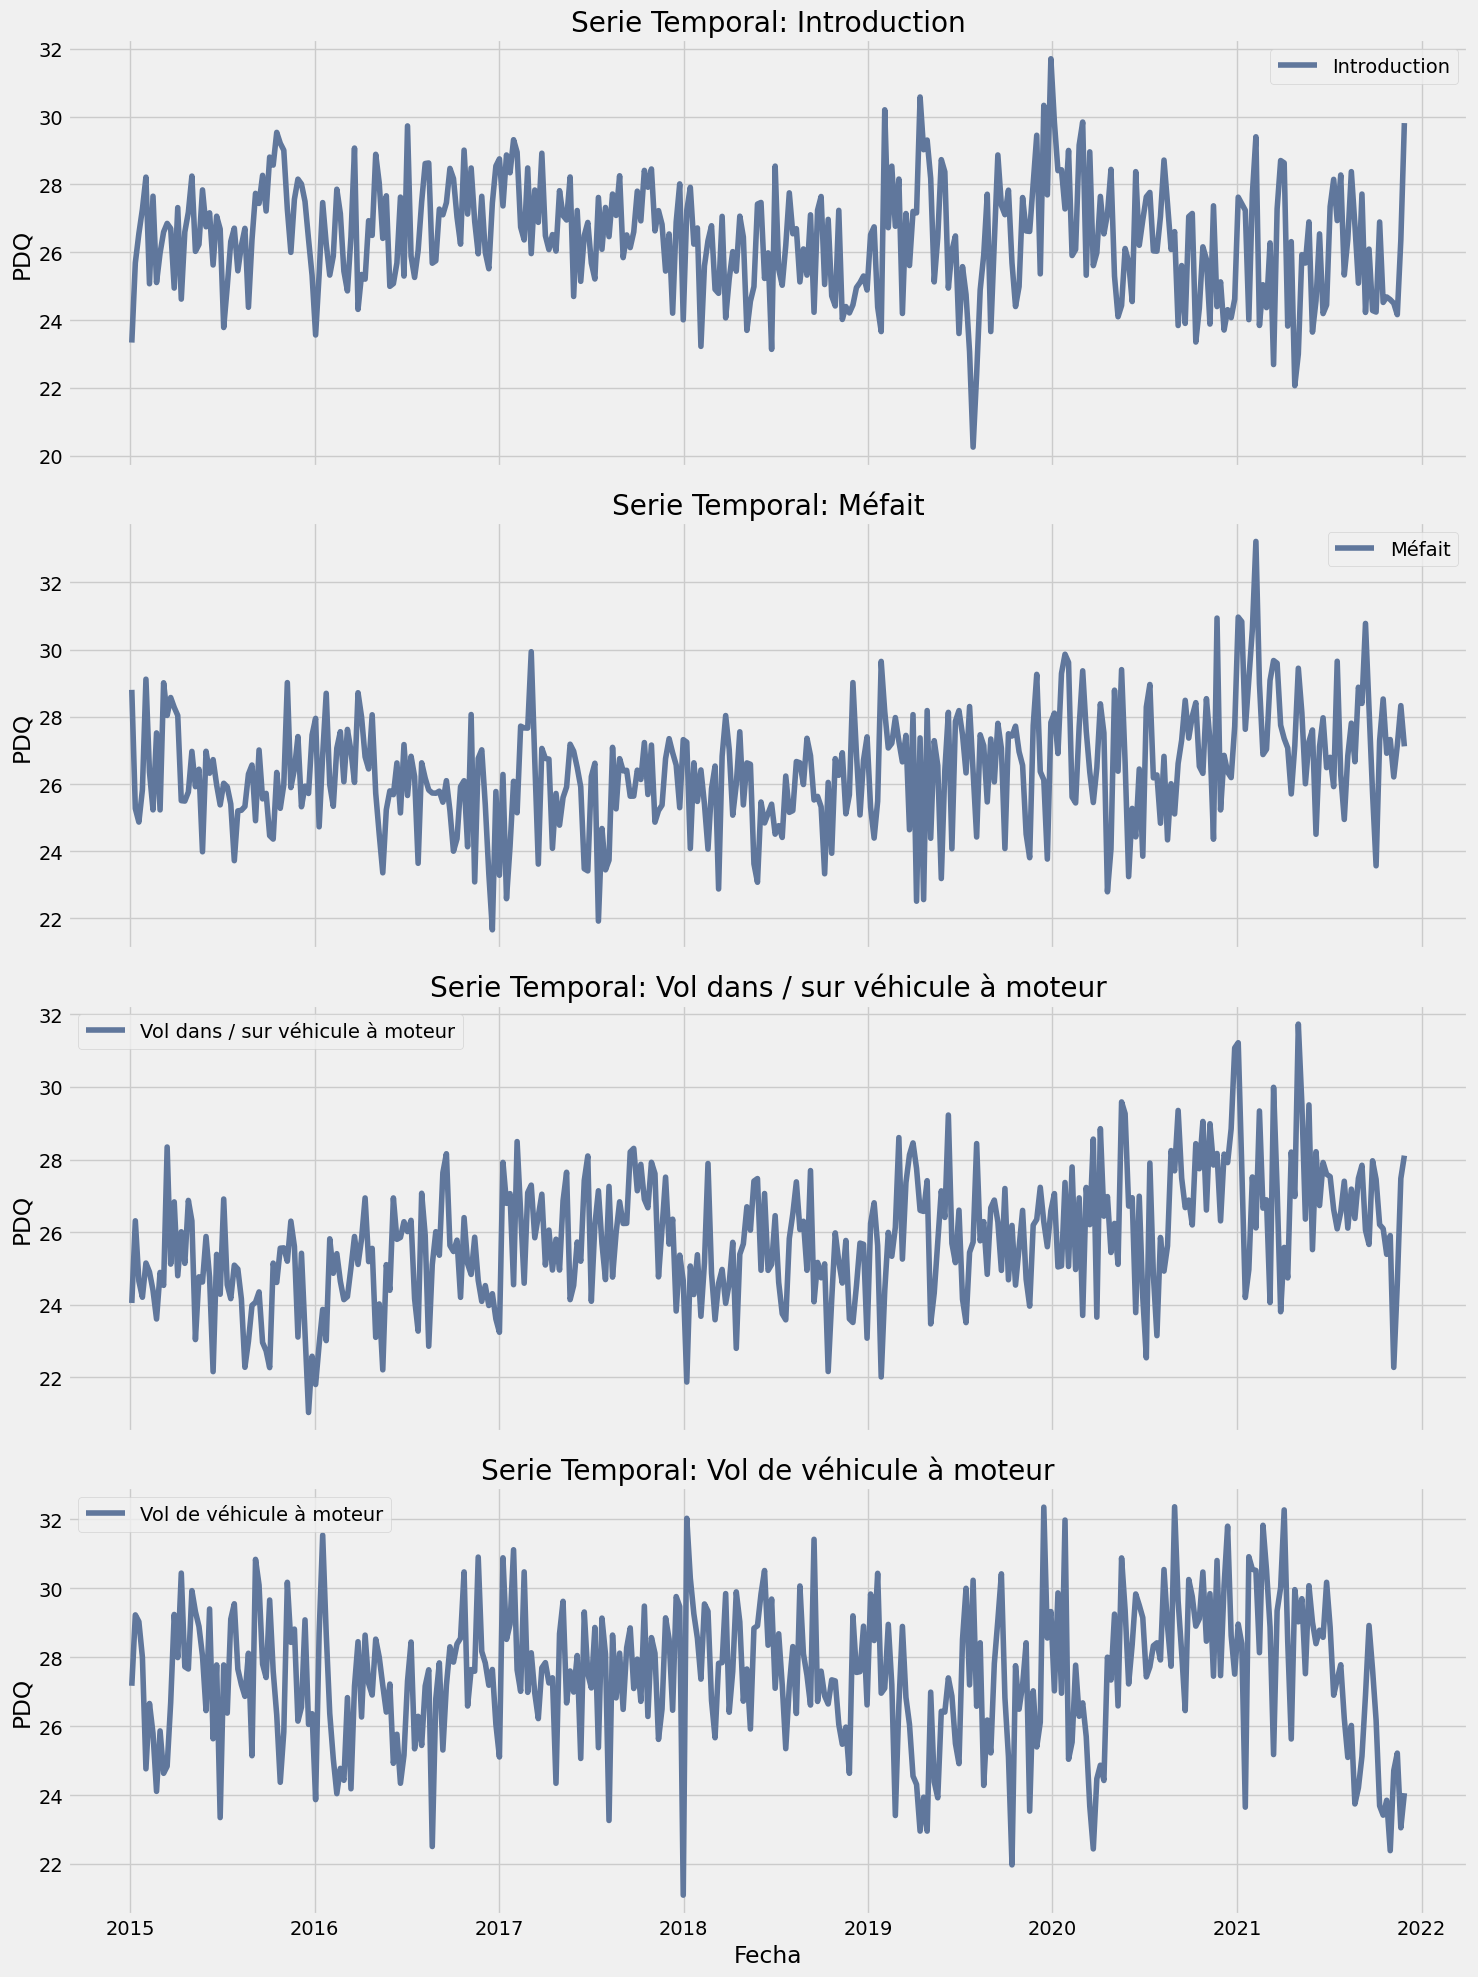

In [9]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(15, 20), sharex=True)

# Plot y_s1
axes[0].plot(y_s1.index, y_s1['pdq'], label=validate_categorie[0])
axes[0].set_title(f'Serie Temporal: {validate_categorie[0]}')
axes[0].set_ylabel('PDQ')
axes[0].legend()

# Plot y_s2
axes[1].plot(y_s2.index, y_s2['pdq'], label=validate_categorie[1])
axes[1].set_title(f'Serie Temporal: {validate_categorie[1]}')
axes[1].set_ylabel('PDQ')
axes[1].legend()

# Plot y_s3
axes[2].plot(y_s3.index, y_s3['pdq'], label=validate_categorie[2])
axes[2].set_title(f'Serie Temporal: {validate_categorie[2]}')
axes[2].set_ylabel('PDQ')
axes[2].legend()

# Plot y_s4
axes[3].plot(y_s4.index, y_s4['pdq'], label=validate_categorie[3])
axes[3].set_title(f'Serie Temporal: {validate_categorie[3]}')
axes[3].set_xlabel('Fecha')
axes[3].set_ylabel('PDQ')
axes[3].legend()

plt.tight_layout()
plt.show()



2. Seleccione una de las series temporales \$y\_{si}, ; i=1,2,3,4\$ y desarrolle lo siguiente:

* **Análisis exploratorio**: examine la serie elegida identificando patrones, tendencias y posibles estacionalidades.
* **Modelado con SARIMA**: ajuste un modelo \$SARIMA(p,d,q) \times (P,D,Q,S)\$ probando distintas configuraciones de hiperparámetros. Compare resultados, seleccione la mejor configuración y justifique su elección.
* **Validación del modelo**: evalúe los residuos del modelo óptimo y determine si se comportan como **ruido blanco**.

> **Nota**: Utilice como `target_date` = `'2021-01-01'`. Recuerde que la columna de valores se llama `pdq`.



In [6]:
# creando clase SarimaModels

class SarimaModels:
    def __init__(self,params):

        self.params = params


    @property
    def name_model(self):
        return f"SARIMA_{self.params[0]}X{self.params[1]}".replace(' ','')

    @staticmethod
    def test_train_model(y,date):
        mask_ds = y.index < date

        y_train = y[mask_ds]
        y_test = y[~mask_ds]

        return y_train, y_test

    def fit_model(self,y,date):
        y_train, y_test = self.test_train_model(y,date )
        model = SARIMAX(y_train,
                        order=self.params[0],
                        seasonal_order=self.params[1],
                        enforce_stationarity=False,
                        enforce_invertibility=False)

        model_fit = model.fit(disp=0)

        return model_fit

    def df_testig(self,y,date):
        y_train, y_test = self.test_train_model(y,date )
        model = SARIMAX(y_train,
                        order=self.params[0],
                        seasonal_order=self.params[1],
                        enforce_stationarity=False,
                        enforce_invertibility=False)

        model_fit = model.fit(disp=0)

        start_index = y_test.index.min()
        end_index = y_test.index.max()

        preds = model_fit.get_prediction(start=start_index,end=end_index, dynamic=False)
        df_temp = pd.DataFrame(
            {
                'y':y_test['pdq'],
                'yhat': preds.predicted_mean
            }
        )

        return df_temp

    def metrics(self,y,date):
        df_temp = self.df_testig(y,date)
        df_metrics = summary_metrics(df_temp)
        df_metrics['model'] = self.name_model

        return df_metrics

# definir parametros

import itertools

p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

params = list(itertools.product(pdq,seasonal_pdq))
target_date = '2021-01-01'

### Análisis Exploratorio para la Serie Temporal: Introduction ###



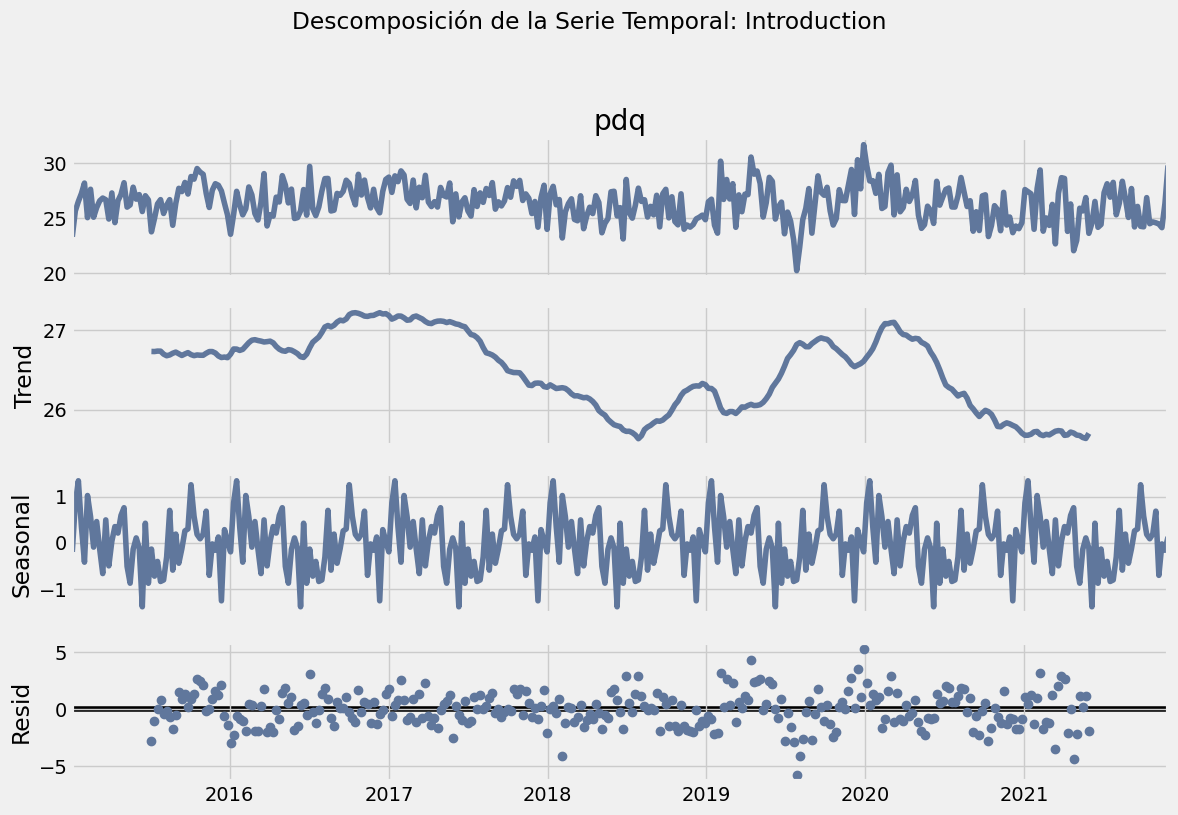


Observaciones del análisis exploratorio:

 - **Tendencia (Trend)**: La gráfica de tendencia muestra la dirección a largo plazo de la serie, suavizando las fluctuaciones estacionales e irregulares.
 - **Estacionalidad (Seasonal)**: La gráfica de estacionalidad revela patrones que se repiten en intervalos regulares, en este caso, patrones anuales debido al periodo de 52 semanas.
 - **Residuos (Residual)**: La gráfica de residuos muestra la parte de la serie que no puede explicarse por la tendencia ni la estacionalidad. Idealmente, estos deberían parecer ruido blanco.


In [10]:
print(f"### Análisis Exploratorio para la Serie Temporal: {validate_categorie[0]} ###\n")

# Descomposición aditiva de la serie temporal y_s1
decomposition = sm.tsa.seasonal_decompose(y_s1['pdq'], model='additive', period=52) # Periodo de 52 semanas para estacionalidad anual

# Visualización de los componentes de la descomposición
fig = decomposition.plot()
fig.set_size_inches(12, 8)
fig.suptitle(f'Descomposición de la Serie Temporal: {validate_categorie[0]}', y=1.02) # Ajustar el título global
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Ajustar el layout para evitar solapamiento del título
plt.show()

print("\nObservaciones del análisis exploratorio:\n")
print(" - **Tendencia (Trend)**: La gráfica de tendencia muestra la dirección a largo plazo de la serie, suavizando las fluctuaciones estacionales e irregulares.")
print(" - **Estacionalidad (Seasonal)**: La gráfica de estacionalidad revela patrones que se repiten en intervalos regulares, en este caso, patrones anuales debido al periodo de 52 semanas.")
print(" - **Residuos (Residual)**: La gráfica de residuos muestra la parte de la serie que no puede explicarse por la tendencia ni la estacionalidad. Idealmente, estos deberían parecer ruido blanco.")




3. Resuelva el ejercicio anterior utilizando la librería **`Prophet`**, desarrollada por Facebook para el modelado de series temporales.

* **Ajuste del modelo**: entrene un modelo con `Prophet` sobre la misma serie seleccionada en el punto anterior.
* **Evaluación del desempeño**: compare la capacidad predictiva de `Prophet` frente al modelo **SARIMA** previamente ajustado, considerando métricas de error (por ejemplo, MAE, RMSE o MAPE).
* **Análisis comparativo**: discuta las diferencias en los supuestos de ambos métodos, su facilidad de implementación y la calidad de las predicciones obtenidas.
* **Conclusiones**: señale en qué situaciones `Prophet` puede ser preferible a SARIMA y viceversa.


### Modelado con Prophet para la Serie Temporal: Introduction ###



INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Métricas de Prophet:
      mae     mse    rmse   mape   maape  wmape   mmape   smape    model
0  1.7068  4.1274  2.0316  0.067  0.0667  0.066  0.0644  0.0659  Prophet


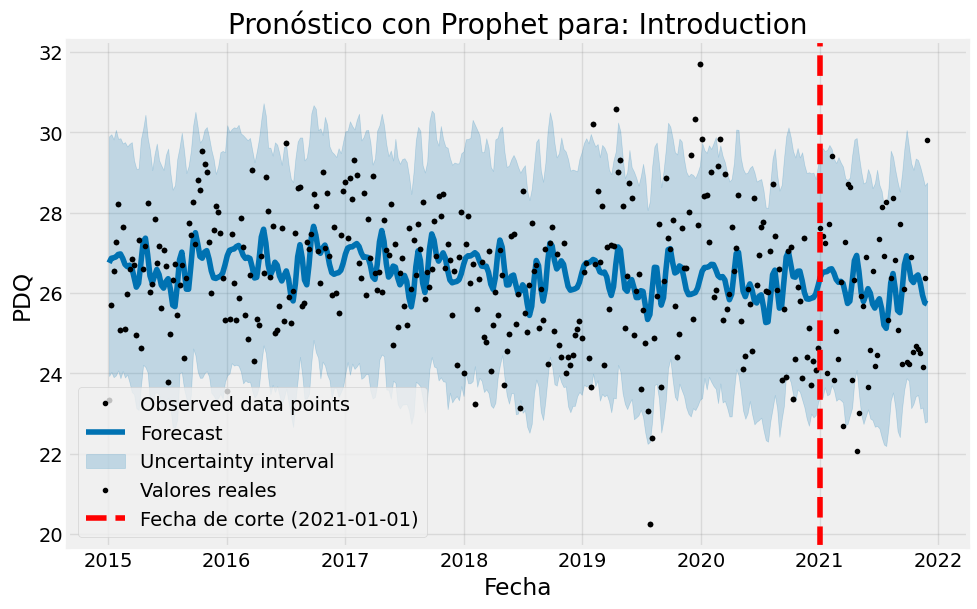

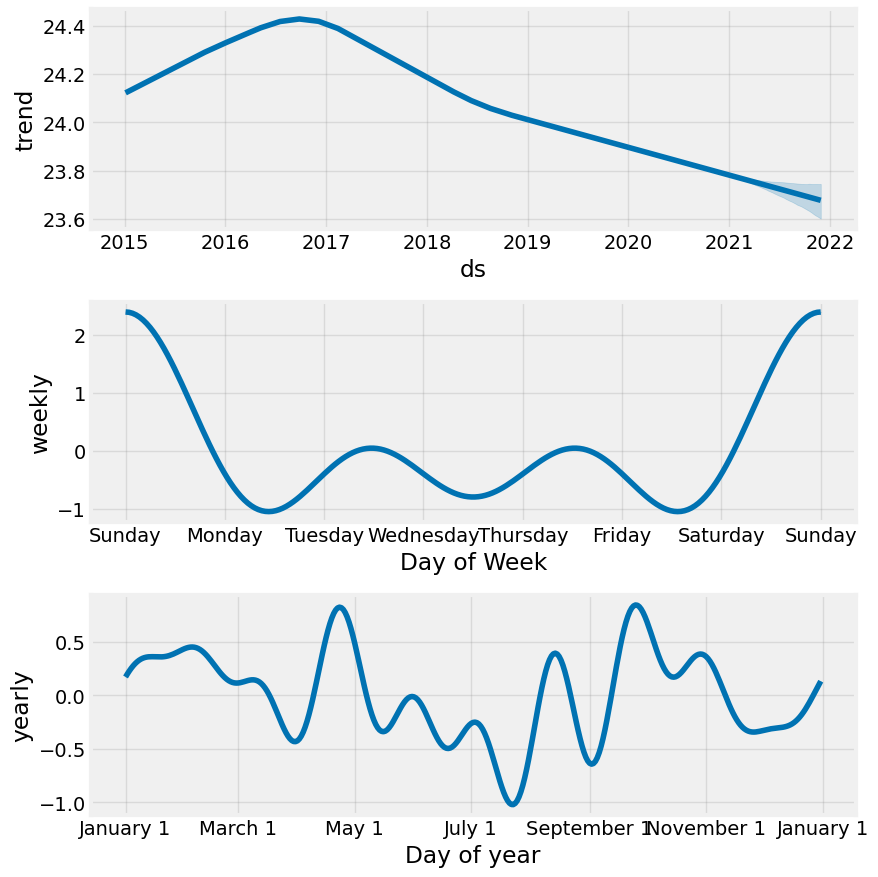

In [11]:
from prophet import Prophet

print(f"### Modelado con Prophet para la Serie Temporal: {validate_categorie[0]} ###\n")

# Preparar los datos para Prophet (ds y y)
prophet_df = y_s1.reset_index().rename(columns={'date': 'ds', 'pdq': 'y'})

# Dividir los datos en entrenamiento y prueba
prophet_train = prophet_df[prophet_df['ds'] < target_date]
prophet_test = prophet_df[prophet_df['ds'] >= target_date]

# Inicializar y ajustar el modelo Prophet
model = Prophet(
    seasonality_mode='additive',
    weekly_seasonality=True,  # Asumiendo estacionalidad semanal ya que los datos son semanales
    yearly_seasonality=True,  # Asumiendo estacionalidad anual por el periodo de 52 semanas
    interval_width=0.95 # Intervalo de confianza del 95%
)
model.fit(prophet_train)

# Crear un dataframe para las futuras predicciones
future = model.make_future_dataframe(periods=len(prophet_test), freq='W')

# Realizar predicciones
forecast = model.predict(future)

# Unir las predicciones con los valores reales para el conjunto de prueba
prophet_preds = forecast[['ds', 'yhat']].set_index('ds').loc[prophet_test['ds']]
prophet_preds = prophet_preds.merge(prophet_test.set_index('ds'), left_index=True, right_index=True)

# Calcular métricas
prophet_metrics_df = summary_metrics(prophet_preds.rename(columns={'yhat': 'yhat', 'y': 'y'}))
prophet_metrics_df['model'] = 'Prophet'

print("Métricas de Prophet:")
print(prophet_metrics_df)

# Visualizar las predicciones
fig_prophet = model.plot(forecast)
plt.title(f'Pronóstico con Prophet para: {validate_categorie[0]}')
plt.xlabel('Fecha')
plt.ylabel('PDQ')

# Añadir los puntos reales de la serie temporal a la gráfica
plt.plot(prophet_df['ds'], prophet_df['y'], 'k.', label='Valores reales')

# Resaltar la parte de entrenamiento y prueba
plt.axvline(x=pd.to_datetime(target_date), color='r', linestyle='--', label='Fecha de corte (2021-01-01)')
plt.legend()
plt.show()

fig_components = model.plot_components(forecast)
plt.show()